### **Практическая работа \#4. Анализ системы с приоритетами.**

#### Выполнил: **Черных Арсений Игоревич**
#### Группа: **М3303**
#### Тема: **Система обработки сетевых запросов (Web-сервер)**

**Цель работы:**  
Исследовать характеристики системы массового обслуживания с приоритетами и проанализировать влияние приоритетов на время ожидания и эффективность системы.

---

### **Задачи:**

1. Разработать математическую модель системы с приоритетами.  
2. Провести расчеты основных характеристик системы для различных классов заявок.  
3. Проанализировать влияние приоритетов на время ожидания и эффективность системы.

---

### **Исходные данные:**

* Интенсивность входящего потока заявок:  
  * Высокоприоритетные заявки (λ₁): задается вариантом (например, 3 заявки/час).  
  * Низкоприоритетные заявки (λ₂): задается вариантом (например, 5 заявок/час).  
* Интенсивность обслуживания (μ): задается вариантом (например, 10 заявок/час).  
* Тип приоритета: абсолютный (высокоприоритетные заявки обслуживаются в первую очередь).

---

### **Шаги выполнения работы:**

1. Разработка модели:  
   * Опишите систему массового обслуживания с двумя классами заявок: высокоприоритетные и низкоприоритетные.  
   * Учтите, что высокоприоритетные заявки обслуживаются в первую очередь, независимо от наличия низкоприоритетных заявок в очереди.  
2. Расчет характеристик системы:  
   * Рассчитайте следующие показатели для каждого класса заявок:  
     * Среднее время ожидания в очереди.  
     * Среднее время пребывания в системе.  
     * Вероятность того, что заявка будет ждать в очереди.  
   * Рассчитайте общие характеристики системы:  
     * Коэффициент загрузки системы.  
     * Среднее число заявок в системе.  
3. Анализ результатов:  
   * Сравните время ожидания и время пребывания для высокоприоритетных и низкоприоритетных заявок.  
   * Постройте графики зависимости времени ожидания от интенсивности входящего потока для каждого класса заявок.  
   * Сделайте выводы о влиянии приоритетов на эффективность системы.

---

### **Требования к отчету:**

1. Описание модели:  
   * Краткое описание системы и ее параметров.  
   * Формулы, используемые для расчетов.  
2. Результаты расчетов:  
   * Таблицы с рассчитанными характеристиками системы для каждого класса заявок.  
   * Графики зависимостей времени ожидания от интенсивности входящего потока.  
3. Анализ результатов:  
   * Выводы о работе системы и рекомендации по ее оптимизации.

---

### **Инструменты для выполнения работы:**

* Язык программирования: Python (библиотеки `numpy`, `scipy`, `matplotlib`).  
* Программное обеспечение: Excel, MATLAB (по выбору).



## Модель системы

Рассматривается одноканальная система массового обслуживания (M/M/1) с двумя классами заявок:

- класс 1 — высокий приоритет
- класс 2 — низкий приоритет

Потоки заявок — пуассоновские:
- λ1 — высокий приоритет
- λ2 — низкий приоритет

Время обслуживания — экспоненциальное (μ).

Дисциплина обслуживания - абсолютный приоритет:
сначала обслуживаются заявки высокого приоритета


## Основные обозначения и формулы

Обозначим:

- $ \lambda_1 $ — интенсивность потока высокоприоритетных заявок
- $ \lambda_2 $ — интенсивность потока низкоприоритетных заявок
- $ \mu $ — интенсивность обслуживания
- $ \rho_1 = \dfrac{\lambda_1}{\mu} $
- $ \rho_2 = \dfrac{\lambda_2}{\mu} $
- $ \rho = \rho_1 + \rho_2 = \dfrac{\lambda_1 + \lambda_2}{\mu} $

Условие устойчивости системы:

$ \rho < 1 $

Для одноканальной системы с абсолютными приоритетами и экспоненциальным временем обслуживания:

$ E[S] = \dfrac{1}{\mu} $

$ E[S^2] = \dfrac{2}{\mu^2} $

Введём вспомогательную величину:

$ W_0 = \dfrac{\lambda_1 + \lambda_2}{\mu^2} $

Тогда среднее время ожидания в очереди:

для высокого приоритета:

$ W_{q1} = \dfrac{W_0}{1 - \rho_1} $

для низкого приоритета:

$ W_{q2} = \dfrac{W_0}{(1 - \rho_1)(1 - \rho)} $

Среднее время пребывания в системе:

$ T_1 = W_{q1} + \dfrac{1}{\mu} $

$ T_2 = W_{q2} + \dfrac{1}{\mu} $

Среднее число заявок в системе в целом:

$ L = \dfrac{\rho}{1 - \rho} $

По формуле Литтла для классов:

$ L_1 = \lambda_1 T_1 $

$ L_2 = \lambda_2 T_2 $

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [55]:
def theoretical_metrics(lambda1, lambda2, mu):
    rho1 = lambda1 / mu
    rho2 = lambda2 / mu
    rho = rho1 + rho2

    if rho >= 1:
        raise ValueError("Система неустойчива")

    W0 = (lambda1 + lambda2) / (mu ** 2)

    Wq1 = W0 / (1 - rho1)
    Wq2 = W0 / ((1 - rho1) * (1 - rho))

    T1 = Wq1 + 1 / mu
    T2 = Wq2 + 1 / mu

    L = rho / (1 - rho)

    return {
        "rho": rho,
        "Wq1": Wq1,
        "Wq2": Wq2,
        "T1": T1,
        "T2": T2,
        "L": L,
    }

In [56]:
def simulate(lambda1, lambda2, mu, T=10000, seed=42):
    rng = np.random.default_rng(seed)

    rho = (lambda1 + lambda2) / mu
    if rho >= 1:
        raise ValueError("Система неустойчива: нужно, чтобы lambda1 + lambda2 < mu")

    t = 0.0

    next_arrival_1 = rng.exponential(1 / lambda1) if lambda1 > 0 else np.inf
    next_arrival_2 = rng.exponential(1 / lambda2) if lambda2 > 0 else np.inf
    next_departure = np.inf

    queue_1 = []
    queue_2 = []

    server_busy = False
    current_arrival_time = 0.0
    current_class = 0

    wait_1 = []
    wait_2 = []
    system_1 = []
    system_2 = []

    area = 0.0
    last_t = 0.0

    while t < T:
        next_event = min(next_arrival_1, next_arrival_2, next_departure)

        n_system = len(queue_1) + len(queue_2) + (1 if server_busy else 0)
        area += n_system * (next_event - last_t)
        last_t = next_event

        t = next_event

        if t == next_arrival_1:
            service_time = rng.exponential(1 / mu)

            if not server_busy:
                server_busy = True
                current_arrival_time = t
                current_class = 1
                next_departure = t + service_time

                wait_1.append(0.0)
                system_1.append(service_time)
            else:
                queue_1.append((t, service_time))

            next_arrival_1 = t + rng.exponential(1 / lambda1)

        elif t == next_arrival_2:
            service_time = rng.exponential(1 / mu)

            if not server_busy and len(queue_1) == 0:
                server_busy = True
                current_arrival_time = t
                current_class = 2
                next_departure = t + service_time

                wait_2.append(0.0)
                system_2.append(service_time)
            else:
                queue_2.append((t, service_time))

            next_arrival_2 = t + rng.exponential(1 / lambda2)

        else:
            if queue_1:
                arrival_time, service_time = queue_1.pop(0)
                w = t - arrival_time

                wait_1.append(w)
                system_1.append(w + service_time)

                current_arrival_time = arrival_time
                current_class = 1
                next_departure = t + service_time
                server_busy = True

            elif queue_2:
                arrival_time, service_time = queue_2.pop(0)
                w = t - arrival_time

                wait_2.append(w)
                system_2.append(w + service_time)

                current_arrival_time = arrival_time
                current_class = 2
                next_departure = t + service_time
                server_busy = True

            else:
                server_busy = False
                current_class = 0
                next_departure = np.inf

    return {
        "rho": rho,
        "Wq1": np.mean(wait_1) if wait_1 else 0.0,
        "Wq2": np.mean(wait_2) if wait_2 else 0.0,
        "T1": np.mean(system_1) if system_1 else 0.0,
        "T2": np.mean(system_2) if system_2 else 0.0,
        "L": area / T,
    }

In [57]:
lambda1 = 3
lambda2 = 5
mu = 10

theory = theoretical_metrics(lambda1, lambda2, mu)
model = simulate(lambda1, lambda2, mu, T=10000, seed=42)

In [59]:
print("Теоретические значения:")
for k, v in theory.items():
    print(f"{k} = {v:.4f}")

print()

print("Результаты моделирования:")
for k, v in model.items():
    print(f"{k} = {v:.4f}")

Теоретические значения:
rho = 0.8000
Wq1 = 0.1143
Wq2 = 0.5714
T1 = 0.2143
T2 = 0.6714
L = 4.0000

Результаты моделирования:
rho = 0.8000
Wq1 = 0.1156
Wq2 = 0.6096
T1 = 0.2155
T2 = 0.7107
L = 4.2171


In [53]:
lambda1_values = np.linspace(0.5, 4.5, 9)

theory_wq1 = []
theory_wq2 = []
model_wq1 = []
model_wq2 = []

for l1 in lambda1_values:
    th = theoretical_metrics(l1, lambda2, mu)
    md = simulate(l1, lambda2, mu, T=10000, seed=42)

    theory_wq1.append(th["Wq1"])
    theory_wq2.append(th["Wq2"])
    model_wq1.append(md["Wq1"])
    model_wq2.append(md["Wq2"])

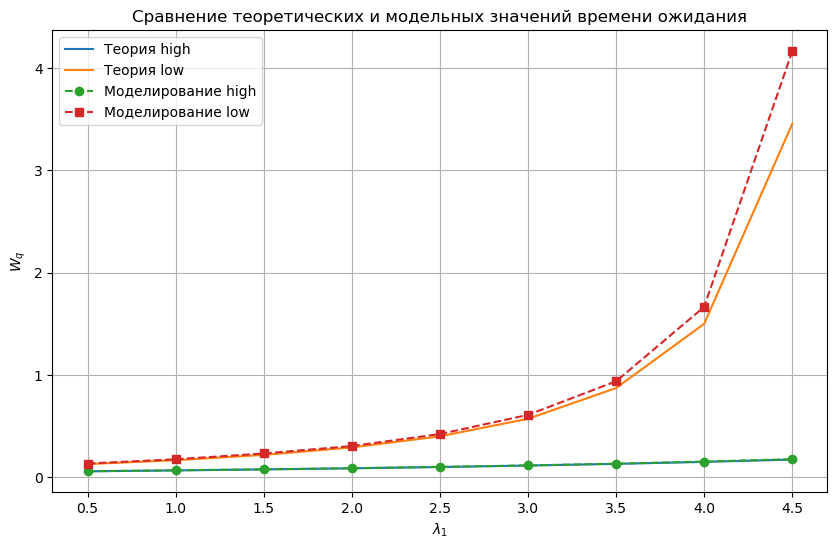

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(lambda1_values, theory_wq1, label="Теория high")
plt.plot(lambda1_values, theory_wq2, label="Теория low")
plt.plot(lambda1_values, model_wq1, "o--", label="Моделирование high")
plt.plot(lambda1_values, model_wq2, "s--", label="Моделирование low")
plt.xlabel(r"$\lambda_1$")
plt.ylabel(r"$W_q$")
plt.title("Сравнение теоретических и модельных значений времени ожидания")
plt.grid(True)
plt.legend()
plt.show()

In [48]:
theory_t1 = []
theory_t2 = []
model_t1 = []
model_t2 = []

for l1 in lambda1_values:
    th = theoretical_metrics(l1, lambda2, mu)
    md = simulate(l1, lambda2, mu, T=10000, seed=42)

    theory_t1.append(th["T1"])
    theory_t2.append(th["T2"])
    model_t1.append(md["T1"])
    model_t2.append(md["T2"])

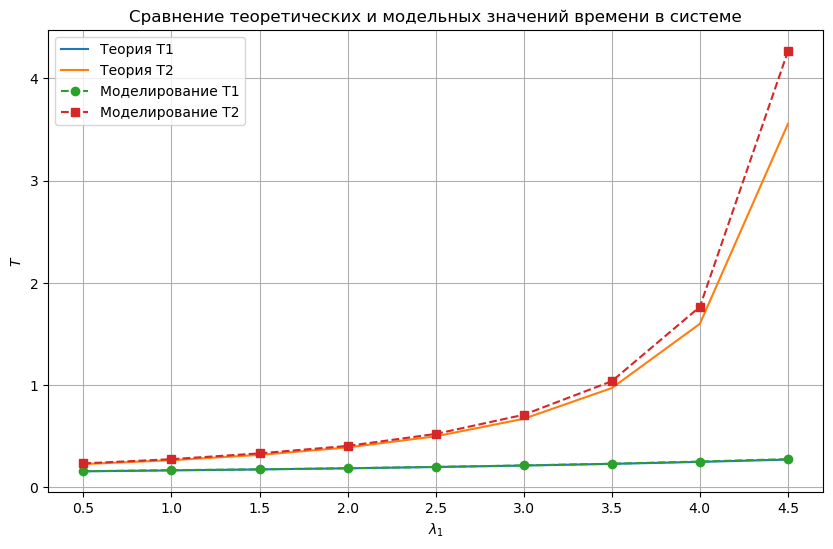

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(lambda1_values, theory_t1, label="Теория T1")
plt.plot(lambda1_values, theory_t2, label="Теория T2")
plt.plot(lambda1_values, model_t1, "o--", label="Моделирование T1")
plt.plot(lambda1_values, model_t2, "s--", label="Моделирование T2")
plt.xlabel(r"$\lambda_1$")
plt.ylabel(r"$T$")
plt.title("Сравнение теоретических и модельных значений времени в системе")
plt.grid(True)
plt.legend()
plt.show()

## Вывод

В ходе лабораторной работы была исследована одноканальная система массового обслуживания с абсолютным приоритетом.

Были получены теоретические значения основных характеристик системы и проведено имитационное моделирование. Сравнение результатов показало хорошее совпадение теоретических и модельных данных, что подтверждает корректность построенной модели.

Анализ графиков показывает, что:

- заявки высокого приоритета имеют значительно меньшее время ожидания и время пребывания в системе;
- заявки низкого приоритета испытывают существенные задержки, особенно при увеличении интенсивности потока высокоприоритетных заявок $ \lambda_1 $;
- при приближении коэффициента загрузки $ \rho $ к 1 время ожидания резко возрастает, особенно для низкоприоритетных заявок.

Таким образом, использование абсолютного приоритета позволяет эффективно обслуживать критически важные заявки, однако приводит к ухудшению качества обслуживания заявок низкого приоритета.

Полученные результаты соответствуют теоретическим ожиданиям и демонстрируют влияние приоритетной дисциплины обслуживания на характеристики системы.